In [104]:
import pandas as pd
import numpy as np
import joblib
import pickle
from tensorflow import keras
from sklearn import metrics
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import regularizers
import warnings
pd.set_option('display.max_columns',None)
warnings.filterwarnings('ignore')

In [62]:
df_test = pd.read_csv("KDDTest.txt")
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22543 entries, 0 to 22542
Data columns (total 43 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   0        22543 non-null  int64  
 1   tcp      22543 non-null  object 
 2   private  22543 non-null  object 
 3   REJ      22543 non-null  object 
 4   0.1      22543 non-null  int64  
 5   0.2      22543 non-null  int64  
 6   0.3      22543 non-null  int64  
 7   0.4      22543 non-null  int64  
 8   0.5      22543 non-null  int64  
 9   0.6      22543 non-null  int64  
 10  0.7      22543 non-null  int64  
 11  0.8      22543 non-null  int64  
 12  0.9      22543 non-null  int64  
 13  0.10     22543 non-null  int64  
 14  0.11     22543 non-null  int64  
 15  0.12     22543 non-null  int64  
 16  0.13     22543 non-null  int64  
 17  0.14     22543 non-null  int64  
 18  0.15     22543 non-null  int64  
 19  0.16     22543 non-null  int64  
 20  0.17     22543 non-null  int64  
 21  0.18     225

In [63]:
columns = (['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot'
,'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations'
,'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate'
,'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count'
,'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate'
,'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','outcome','level'])

In [64]:
df_test.columns = columns

In [65]:
# Manual mapping for protocol_type
protocol_map = {'tcp': 1, 'udp': 2, 'icmp': 3}
df_test['protocol_type'] = df_test['protocol_type'].map(protocol_map)

In [66]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22543 entries, 0 to 22542
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     22543 non-null  int64  
 1   protocol_type                22543 non-null  int64  
 2   service                      22543 non-null  object 
 3   flag                         22543 non-null  object 
 4   src_bytes                    22543 non-null  int64  
 5   dst_bytes                    22543 non-null  int64  
 6   land                         22543 non-null  int64  
 7   wrong_fragment               22543 non-null  int64  
 8   urgent                       22543 non-null  int64  
 9   hot                          22543 non-null  int64  
 10  num_failed_logins            22543 non-null  int64  
 11  logged_in                    22543 non-null  int64  
 12  num_compromised              22543 non-null  int64  
 13  root_shell      

In [67]:
df_test.describe().style.background_gradient(cmap='Blues').set_properties(**{'font-family':'Segoe UI'})

,duration,protocol_type,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,level
count,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000,22543.000000
mean,218.868784,1.208801,10395.911369,2056.110012,0.000311,0.008428,0.000710,0.105399,0.021648,0.442222,0.119904,0.002440,0.000266,0.114670,0.008739,0.001153,0.003549,0.000000,0.000488,0.028435,79.021692,31.125316,0.102928,0.103640,0.238429,0.235145,0.740376,0.094075,0.098115,193.866699,140.756332,0.608747,0.090541,0.132267,0.019639,0.097818,0.099430,0.233351,0.226649,18.017833
std,1407.207069,0.507690,472796.912692,21219.763847,0.017619,0.142602,0.036474,0.928448,0.150331,0.496661,7.269758,0.049335,0.021061,8.041792,0.676857,0.048015,0.067831,0.000000,0.022085,0.166214,128.538218,89.064396,0.295373,0.298337,0.416096,0.416193,0.412479,0.259143,0.253550,94.036867,111.783059,0.435681,0.220722,0.306274,0.085396,0.273144,0.281872,0.387204,0.400851,4.270409
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.250000,0.000000,0.000000,121.000000,15.000000,0.070000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000
50%,0.000000,1.000000,54.000000,46.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,6.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,255.000000,168.000000,0.920000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.000000,1.000000,287.000000,601.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,123.000000,16.000000,0.000000,0.000000,0.250000,0.070000,1.000000,0.060000,0.000000,255.000000,255.000000,1.000000,0.060000,0.030000,0.010000,0.000000,0.000000,0.360000,0.170000,21.000000
max,57715.000000,3.000000,62825648.000000,1345927.000000,1.000000,3.000000,3.000000,101.000000,4.000000,1.000000,796.000000,1.000000,2.000000,878.000000,100.000000,5.000000,4.000000,0.000000,1.000000,1.000000,511.000000,511.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [68]:
df_test.loc[df_test['outcome'] == "normal", "outcome"] = 0
df_test.loc[df_test['outcome'] != 0, "outcome"] = 1

In [69]:
def pie_plot(df, cols_list, rows, cols):
    fig, axes = plt.subplots(rows, cols)
    for ax, col in zip(axes.ravel(), cols_list):
        df[col].value_counts().plot(ax=ax, kind='pie', figsize=(15, 15), fontsize=10, autopct='%1.0f%%')
        ax.set_title(str(col), fontsize = 12)
    plt.show()

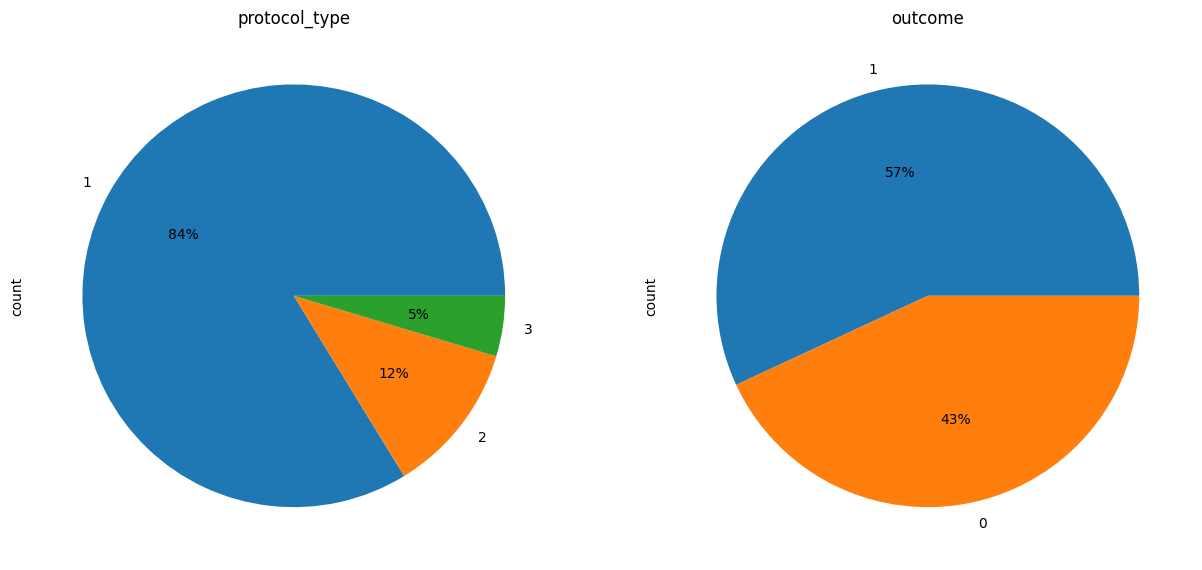

In [70]:
pie_plot(df_test, ['protocol_type', 'outcome'], 1, 2)

In [71]:
df_test.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome,level
0,0,1,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.00,0.0,1.00,1.00,1,21
1,2,1,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.00,0.0,0.00,0.00,0,21
2,0,3,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.00,0.0,0.00,0.00,1,15
3,1,1,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.00,0.0,0.83,0.71,1,11
4,0,1,http,SF,267,14515,0,0,0,0,...,1.00,0.00,0.01,0.03,0.01,0.0,0.00,0.00,0,21


## DATA PREPRCESSING

In [72]:
def preprocess(dataframe, train_columns=None):
    # Numeric columns
    cat_cols = ['is_host_login','protocol_type','service','flag','land', 'logged_in','is_guest_login', 'level', 'outcome']
    df_num = dataframe.drop(cat_cols, axis=1)
    num_cols = df_num.columns

    # Scale numeric columns
    scaler = RobustScaler()
    scaled_df = scaler.fit_transform(df_num)
    scaled_df = pd.DataFrame(scaled_df, columns=num_cols)

    # Combine scaled numeric data with categorical
    dataframe.drop(labels=num_cols, axis="columns", inplace=True)
    dataframe[num_cols] = scaled_df

    # One-hot encode categorical columns
    dataframe = pd.get_dummies(dataframe, columns = ['protocol_type', 'service', 'flag'])

    # Ensure train and test sets have the same columns
    if train_columns is not None:
        missing_cols = set(train_columns) - set(dataframe.columns)
        for col in missing_cols:
            dataframe[col] = 0
        dataframe = dataframe[train_columns]

    return dataframe

In [73]:
model_lr = joblib.load('model_lr.pkl')
train_columns = joblib.load('train_columns.pkl')
train_columns.nunique()

124

In [74]:
scaled_test = preprocess(df_test, train_columns)

In [75]:
test_columns = scaled_test.columns
test_columns.nunique()

124

In [76]:
# Find missing columns in test data
missing_in_test = set(train_columns) - set(test_columns)

# Find extra columns in the test data that aren't in the training data
extra_in_test = set(test_columns) - set(train_columns)

for col in missing_in_test:
    scaled_test[col] = 0

# Remove extra columns from test data
scaled_test = scaled_test.drop(columns=extra_in_test, errors='ignore')

# Ensure the test data columns are in the same order as the train data
scaled_test = scaled_test[train_columns]

print("Test columns after alignment:", scaled_test.columns)

Test columns after alignment: Index(['land', 'logged_in', 'is_host_login', 'is_guest_login', 'outcome',
       'level', 'duration', 'src_bytes', 'dst_bytes', 'wrong_fragment',
       ...
       'flag_REJ', 'flag_RSTO', 'flag_RSTOS0', 'flag_RSTR', 'flag_S0',
       'flag_S1', 'flag_S2', 'flag_S3', 'flag_SF', 'flag_SH'],
      dtype='object', length=124)


In [77]:
scaled_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22543 entries, 0 to 22542
Columns: 124 entries, land to flag_SH
dtypes: bool(75), float64(34), int64(14), object(1)
memory usage: 10.0+ MB


In [78]:
kernal_evals = dict()
def evaluate_classification(model, name, X_train, X_test, y_train, y_test):
    # Predict class labels (apply thresholding for binary classification)
    train_predictions = (model.predict(X_train) > 0.5).astype(int)
    test_predictions = (model.predict(X_test) > 0.5).astype(int)

    # Calculate accuracy, precision, and recall
    train_accuracy = metrics.accuracy_score(y_train, train_predictions)
    test_accuracy = metrics.accuracy_score(y_test, test_predictions)

    train_precision = metrics.precision_score(y_train, train_predictions)
    test_precision = metrics.precision_score(y_test, test_predictions)

    train_recall = metrics.recall_score(y_train, train_predictions)
    test_recall = metrics.recall_score(y_test, test_predictions)

    # Store results in the dictionary
    kernal_evals[str(name)] = [train_accuracy, test_accuracy, train_precision, test_precision, train_recall, test_recall]

    # Print results
    print(f"Training Accuracy {name}: {train_accuracy * 100:.2f}%  Test Accuracy {name}: {test_accuracy * 100:.2f}%")
    print(f"Training Precision {name}: {train_precision * 100:.2f}%  Test Precision {name}: {test_precision * 100:.2f}%")
    print(f"Training Recall {name}: {train_recall * 100:.2f}%  Test Recall {name}: {test_recall * 100:.2f}%")

    # Confusion matrix
    actual = y_test
    confusion_matrix = metrics.confusion_matrix(actual, test_predictions)
    cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=['normal', 'attack'])

    # Plot confusion matrix
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.grid(False)
    cm_display.plot(ax=ax)
    plt.show()

In [79]:
for column in df_test.columns:
    print(column.upper(),':',df_test[column].nunique())
    # print(data_train.value_counts())

PROTOCOL_TYPE : 3
SERVICE : 64
FLAG : 11
LAND : 2
LOGGED_IN : 2
IS_HOST_LOGIN : 2
IS_GUEST_LOGIN : 2
OUTCOME : 2
LEVEL : 22
DURATION : 624
SRC_BYTES : 1149
DST_BYTES : 3650
WRONG_FRAGMENT : 3
URGENT : 4
HOT : 16
NUM_FAILED_LOGINS : 5
NUM_COMPROMISED : 23
ROOT_SHELL : 2
SU_ATTEMPTED : 3
NUM_ROOT : 20
NUM_FILE_CREATIONS : 9
NUM_SHELLS : 4
NUM_ACCESS_FILES : 5
NUM_OUTBOUND_CMDS : 1
COUNT : 495
SRV_COUNT : 457
SERROR_RATE : 88
SRV_SERROR_RATE : 82
RERROR_RATE : 90
SRV_RERROR_RATE : 93
SAME_SRV_RATE : 75
DIFF_SRV_RATE : 99
SRV_DIFF_HOST_RATE : 84
DST_HOST_COUNT : 256
DST_HOST_SRV_COUNT : 256
DST_HOST_SAME_SRV_RATE : 101
DST_HOST_DIFF_SRV_RATE : 101
DST_HOST_SAME_SRC_PORT_RATE : 101
DST_HOST_SRV_DIFF_HOST_RATE : 58
DST_HOST_SERROR_RATE : 99
DST_HOST_SRV_SERROR_RATE : 101
DST_HOST_RERROR_RATE : 101
DST_HOST_SRV_RERROR_RATE : 100


## PCA

In [80]:
x = scaled_test.drop(['outcome', 'level'], axis=1)
print(x.columns)
x = x.values
y = scaled_test['outcome'].values
y_reg = scaled_test['level'].values
pca = PCA(n_components=20)
pca = pca.fit(x)
x_reduced = pca.transform(x)
print("Number of original features is {} and of reduced features is {}".format(x.shape[1], x_reduced.shape[1]))
y = y.astype('int')
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train_reduced, x_test_reduced, y_train_reduced, y_test_reduced = train_test_split(x_reduced, y, test_size=0.2, random_state=42)
x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(x, y_reg, test_size=0.2, random_state=42)

Index(['land', 'logged_in', 'is_host_login', 'is_guest_login', 'duration',
       'src_bytes', 'dst_bytes', 'wrong_fragment', 'urgent', 'hot',
       ...
       'flag_REJ', 'flag_RSTO', 'flag_RSTOS0', 'flag_RSTR', 'flag_S0',
       'flag_S1', 'flag_S2', 'flag_S3', 'flag_SF', 'flag_SH'],
      dtype='object', length=122)
Number of original features is 122 and of reduced features is 20


In [81]:
model_lr = joblib.load('model_lr.pkl')
model_knn = joblib.load('model_knn.pkl')
model_gnb = joblib.load('model_gnb.pkl')
model_linear_svc = joblib.load('model_linear_svc.pkl')
model_tdt = joblib.load('model_tdt.pkl')
model_rf = joblib.load('model_rf.pkl')
model_xg_r = joblib.load('model_xg_r.pkl')
model_rrf = joblib.load('model_rrf.pkl')

In [82]:
try:
    x_train = x_train.astype(np.float32)
    y_train = y_train.astype(np.int32)  # Use float32 if it's a regression problem
    x_test = x_test.astype(np.float32)
    y_test = y_test.astype(np.int32)
    model_history = joblib.load('model_history.pkl')
    print("Model history loaded successfully.")
except Exception as e:
    print("Error loading model history:", e)

Model history loaded successfully.


In [83]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=64, activation='relu', input_shape=(x_train.shape[1:]), 
                          kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4), 
                          bias_regularizer=regularizers.L2(1e-4),
                          activity_regularizer=regularizers.L2(1e-5)),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(units=128, activation='relu', 
                          kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4), 
                          bias_regularizer=regularizers.L2(1e-4),
                          activity_regularizer=regularizers.L2(1e-5)),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(units=512, activation='relu', 
                          kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4), 
                          bias_regularizer=regularizers.L2(1e-4),
                          activity_regularizer=regularizers.L2(1e-5)),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(units=128, activation='relu', 
                          kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4), 
                          bias_regularizer=regularizers.L2(1e-4),
                          activity_regularizer=regularizers.L2(1e-5)),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(units=1, activation='sigmoid'),
])

In [84]:
model.compile(optimizer='adam', loss=tf.keras.losses.BinaryCrossentropy(from_logits=True), metrics=['accuracy'])

In [85]:
x_train = x_train.astype(np.float32)
y_train = y_train.astype(np.int32)  # Use float32 if it's a regression problem
x_test = x_test.astype(np.float32)
y_test = y_test.astype(np.int32)

In [105]:
model_history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=10, verbose=1)

Epoch 1/10
564/564 [==============================] - 5s 10ms/step - loss: 0.1616 - accuracy: 0.9673 - val_loss: 0.1319 - val_accuracy: 0.9723
Epoch 2/10
564/564 [==============================] - 5s 9ms/step - loss: 0.1625 - accuracy: 0.9657 - val_loss: 0.1380 - val_accuracy: 0.9723
Epoch 3/10
564/564 [==============================] - 5s 9ms/step - loss: 0.1824 - accuracy: 0.9675 - val_loss: 0.1338 - val_accuracy: 0.9696
Epoch 4/10
564/564 [==============================] - 5s 9ms/step - loss: 0.1522 - accuracy: 0.9683 - val_loss: 0.1219 - val_accuracy: 0.9716
Epoch 5/10
564/564 [==============================] - 5s 9ms/step - loss: 0.2233 - accuracy: 0.9703 - val_loss: 0.1173 - val_accuracy: 0.9721
Epoch 6/10
564/564 [==============================] - 6s 11ms/step - loss: 0.1773 - accuracy: 0.9682 - val_loss: 0.1847 - val_accuracy: 0.9723
Epoch 7/10
564/564 [==============================] - 6s 11ms/step - loss: 0.1538 - accuracy: 0.9686 - val_loss: 0.1188 - val_accuracy: 0.9721
Epo

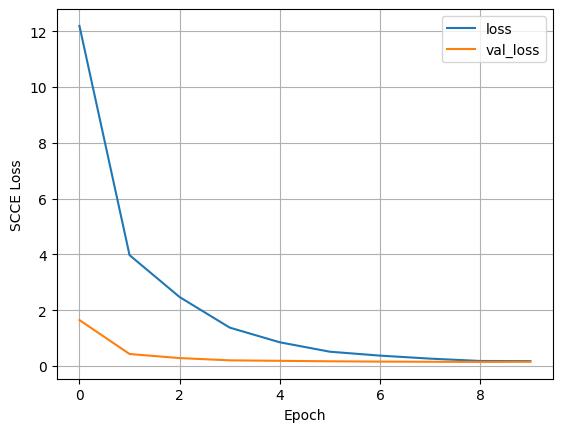

In [87]:
plt.plot(model_history.history['loss'], label='loss')
plt.plot(model_history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('SCCE Loss')
plt.legend()
plt.grid(True)

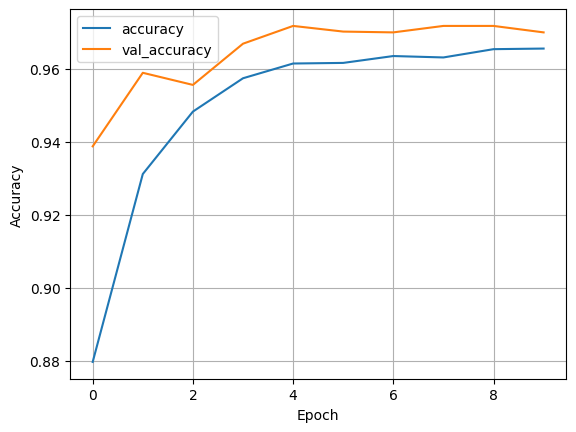

In [88]:
plt.plot(model_history.history['accuracy'], label='accuracy')
plt.plot(model_history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

Training Accuracy RRF: 44.82%  Test Accuracy RRF: 44.49%
Training Precision RRF: 56.00%  Test Precision RRF: 56.69%
Training Recall RRF: 13.53%  Test Recall RRF: 13.12%


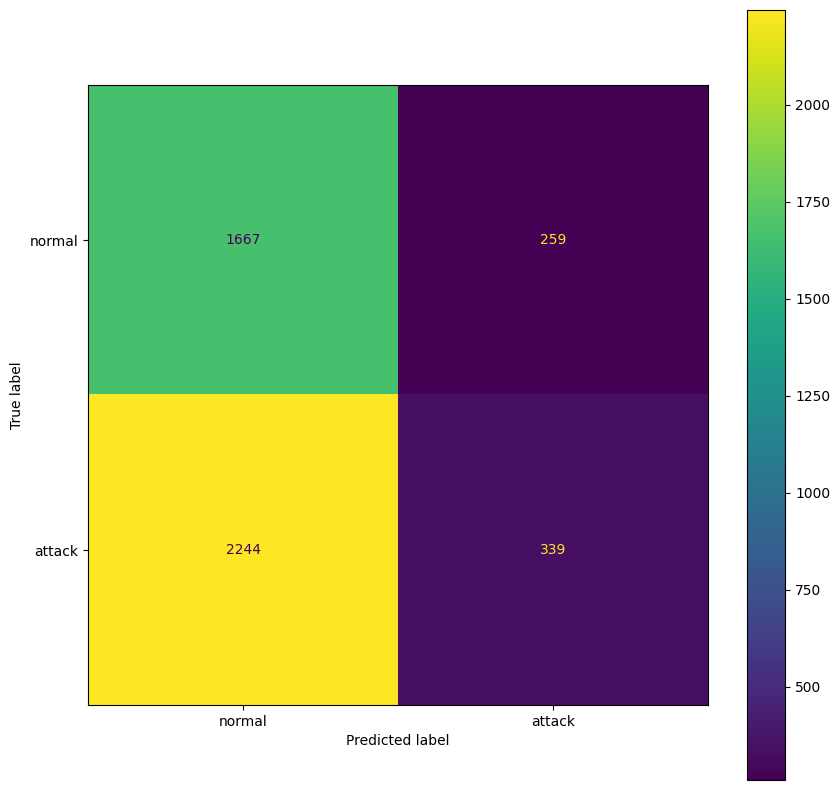

In [89]:
evaluate_classification(model_rrf, "RRF", x_train_reduced, x_test_reduced, y_train_reduced, y_test_reduced)

In [90]:
df_test['protocol_type']
df_test['protocol_type'] = df_test['protocol_type'].astype(float)
print(scaled_test.nunique())
x_train = pd.DataFrame(x_train)
print(x_train.columns)

land              2
logged_in         2
is_host_login     2
is_guest_login    2
outcome           2
                 ..
flag_S1           2
flag_S2           2
flag_S3           2
flag_SF           2
flag_SH           2
Length: 124, dtype: int64
RangeIndex(start=0, stop=122, step=1)


In [92]:
def convert_to_numeric(df):
    for column in df.columns:
        if df[column].dtype == 'object':
            try:
                df[column] = pd.to_numeric(df[column])
            except ValueError:
                df[column] = df[column].astype('category').cat.codes
    return df
x_train = convert_to_numeric(pd.DataFrame(x_train))
x_test = convert_to_numeric(pd.DataFrame(x_test))
print("Evaluating models on the new test data...")

Evaluating models on the new test data...


Training Accuracy Logistic Regression: 80.90%  Test Accuracy Logistic Regression: 80.53%
Training Precision Logistic Regression: 92.69%  Test Precision Logistic Regression: 93.65%
Training Recall Logistic Regression: 72.08%  Test Recall Logistic Regression: 70.81%


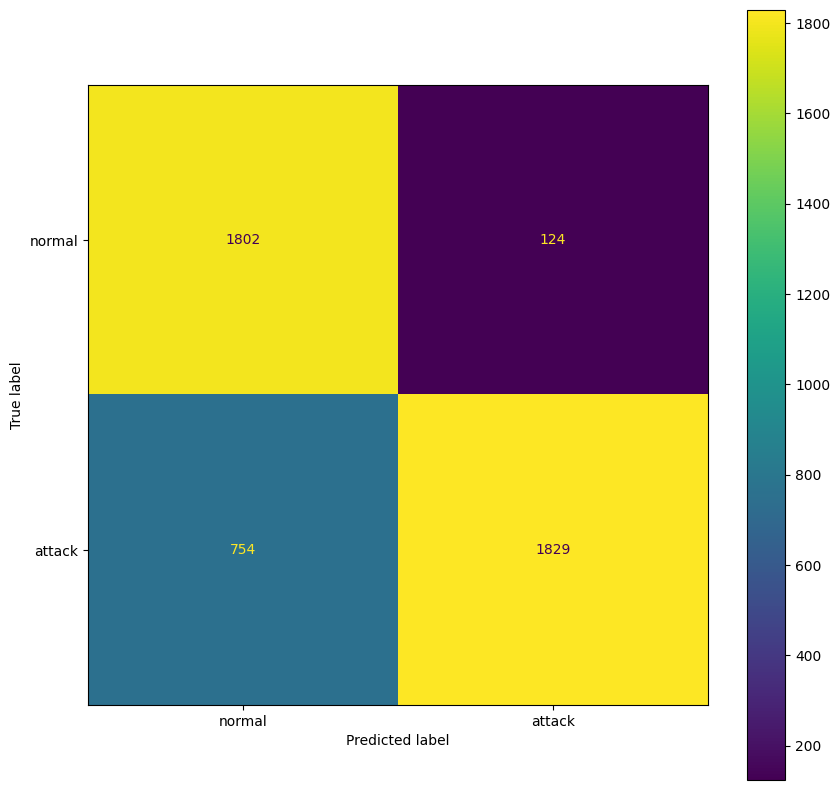

In [93]:
evaluate_classification(model_lr, "Logistic Regression", x_train, x_test, y_train, y_test)

Training Accuracy KNN: 77.37%  Test Accuracy KNN: 75.91%
Training Precision KNN: 95.74%  Test Precision KNN: 95.50%
Training Recall KNN: 62.98%  Test Recall KNN: 60.82%


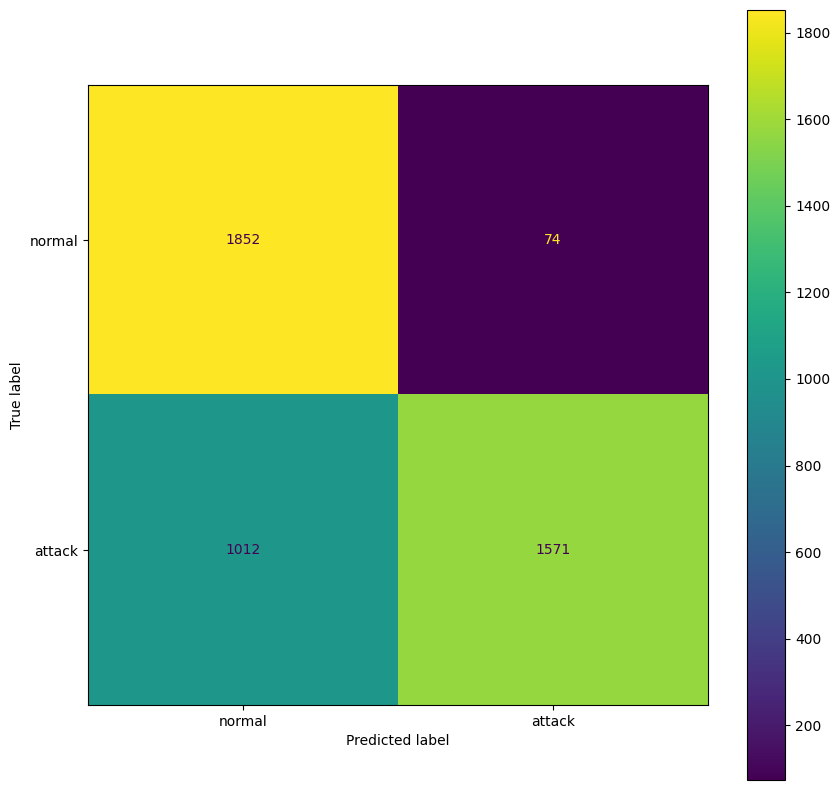

In [94]:
evaluate_classification(model_knn, "KNN", x_train, x_test, y_train, y_test)

Training Accuracy GaussianNB: 81.98%  Test Accuracy GaussianNB: 81.35%
Training Precision GaussianNB: 89.69%  Test Precision GaussianNB: 89.99%
Training Recall GaussianNB: 77.16%  Test Recall GaussianNB: 75.88%


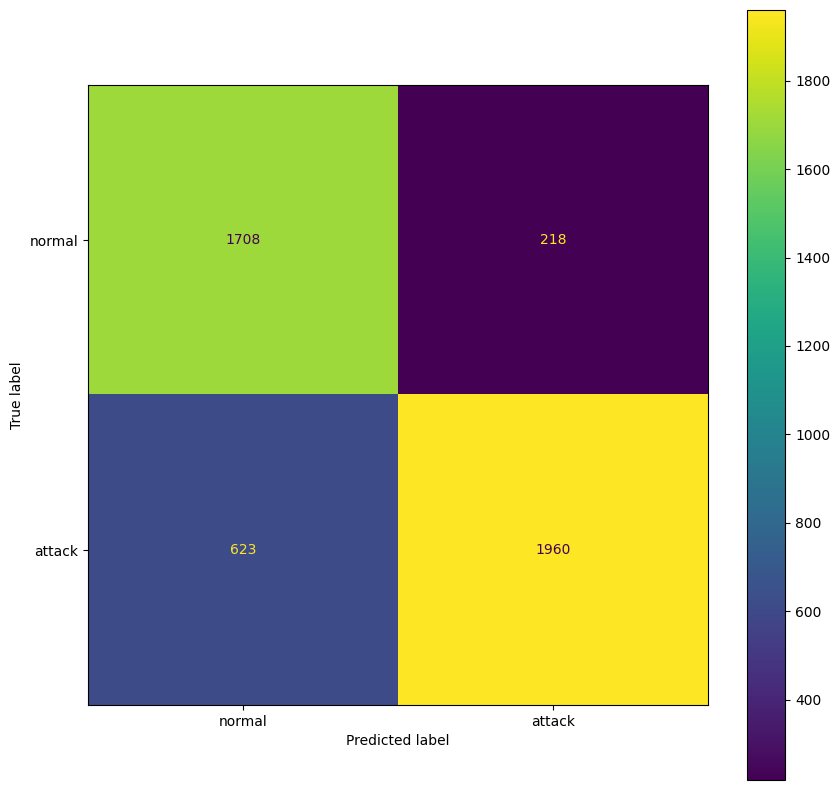

In [95]:

evaluate_classification(model_gnb, "GaussianNB", x_train, x_test, y_train, y_test)

Training Accuracy Decision Tree: 83.46%  Test Accuracy Decision Tree: 82.24%
Training Precision Decision Tree: 94.28%  Test Precision Decision Tree: 94.55%
Training Recall Decision Tree: 75.47%  Test Recall Decision Tree: 73.21%


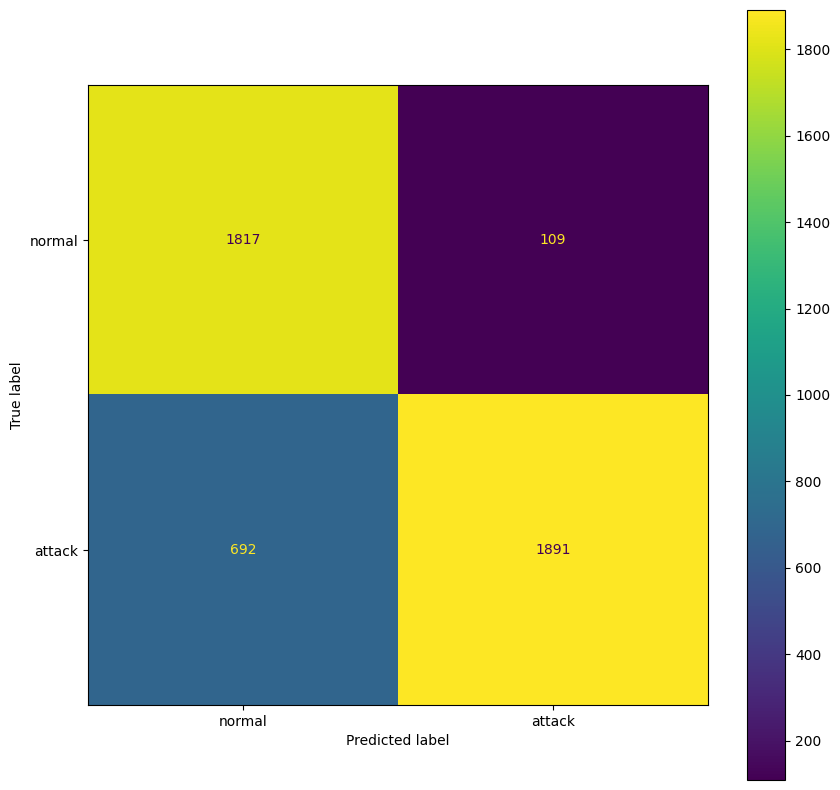

In [96]:

evaluate_classification(model_tdt, "Decision Tree", x_train, x_test, y_train, y_test)

Training Accuracy Random Forest: 80.49%  Test Accuracy Random Forest: 79.06%
Training Precision Random Forest: 95.56%  Test Precision Random Forest: 95.65%
Training Recall Random Forest: 68.88%  Test Recall Random Forest: 66.47%


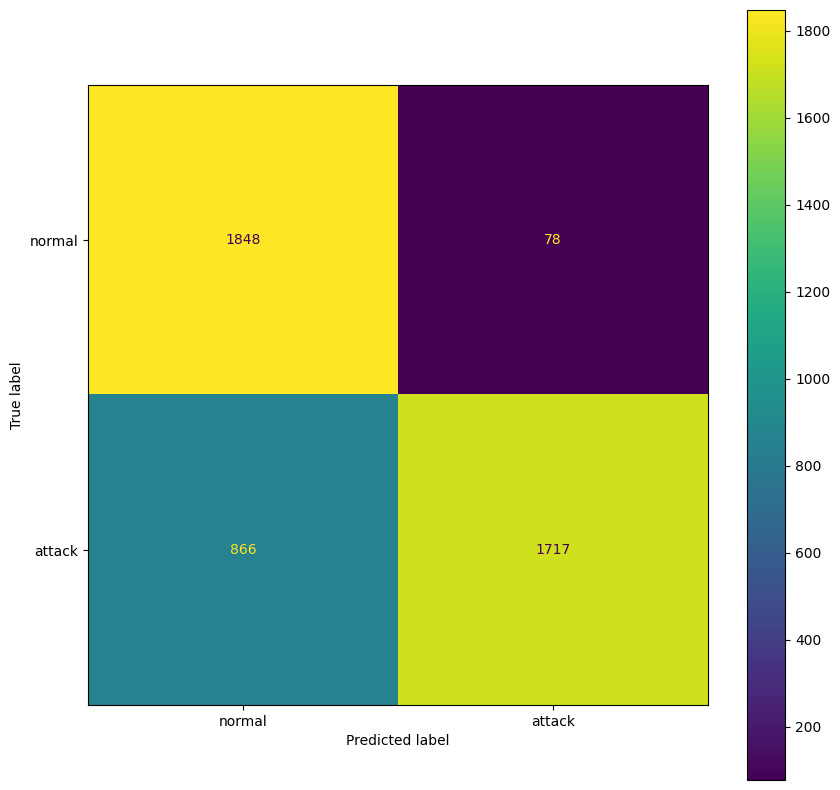

In [97]:

evaluate_classification(model_rf, "Random Forest", x_train, x_test, y_train, y_test)

Training Accuracy XGBoost: 56.83%  Test Accuracy XGBoost: 57.29%
Training Precision XGBoost: 56.83%  Test Precision XGBoost: 57.29%
Training Recall XGBoost: 100.00%  Test Recall XGBoost: 100.00%


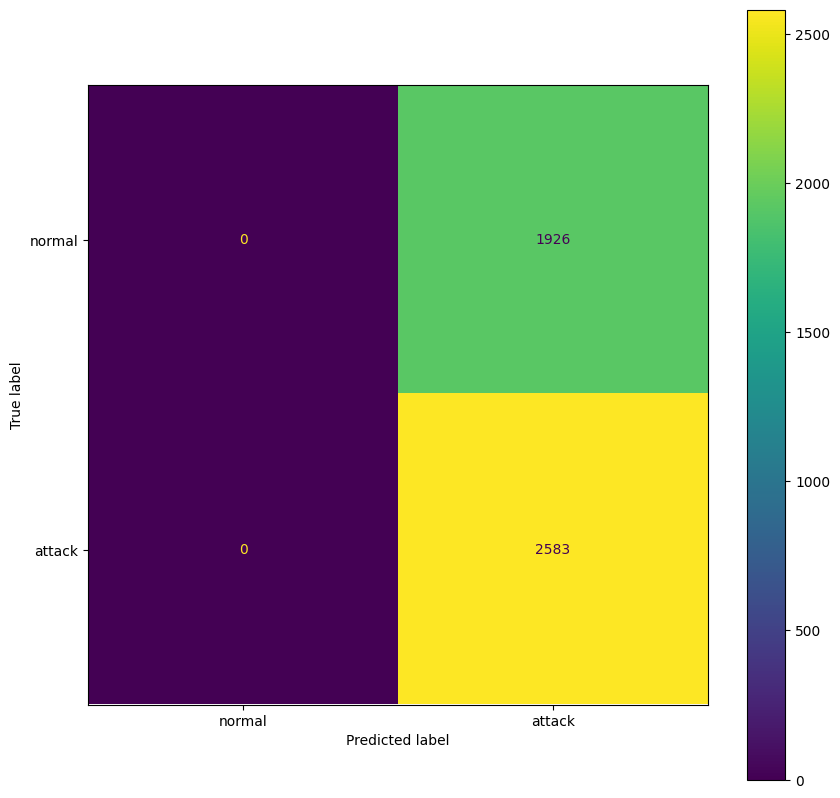

In [98]:

evaluate_classification(model_xg_r, "XGBoost", x_train, x_test, y_train, y_test)

Training Accuracy Linear SVC: 79.82%  Test Accuracy Linear SVC: 78.73%
Training Precision Linear SVC: 86.66%  Test Precision Linear SVC: 86.64%
Training Recall Linear SVC: 76.21%  Test Recall Linear SVC: 74.33%


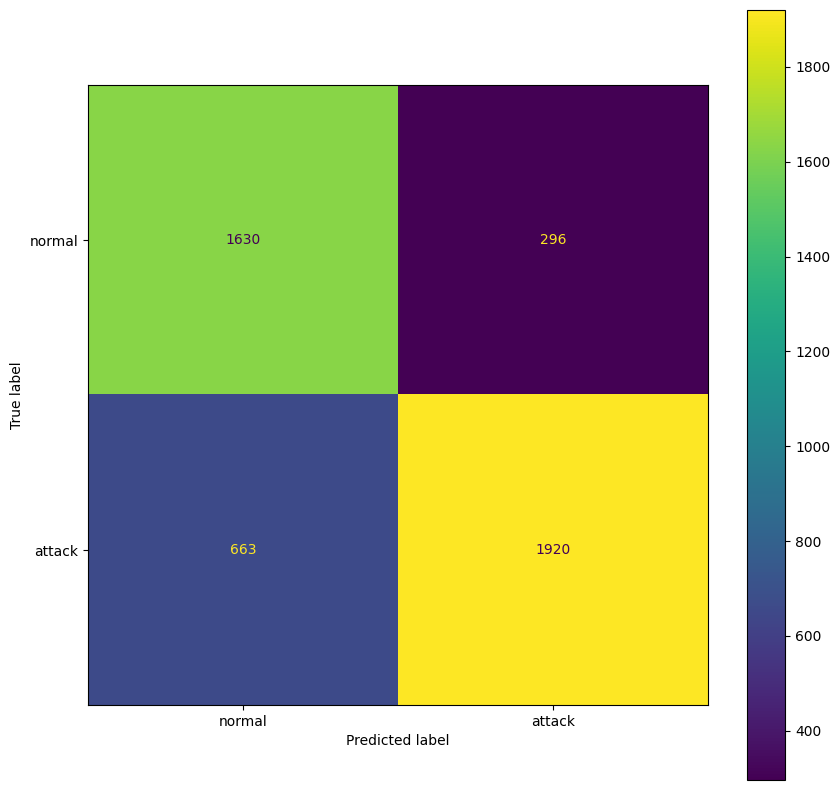

In [99]:
evaluate_classification(model_linear_svc, "Linear SVC", x_train, x_test, y_train, y_test)

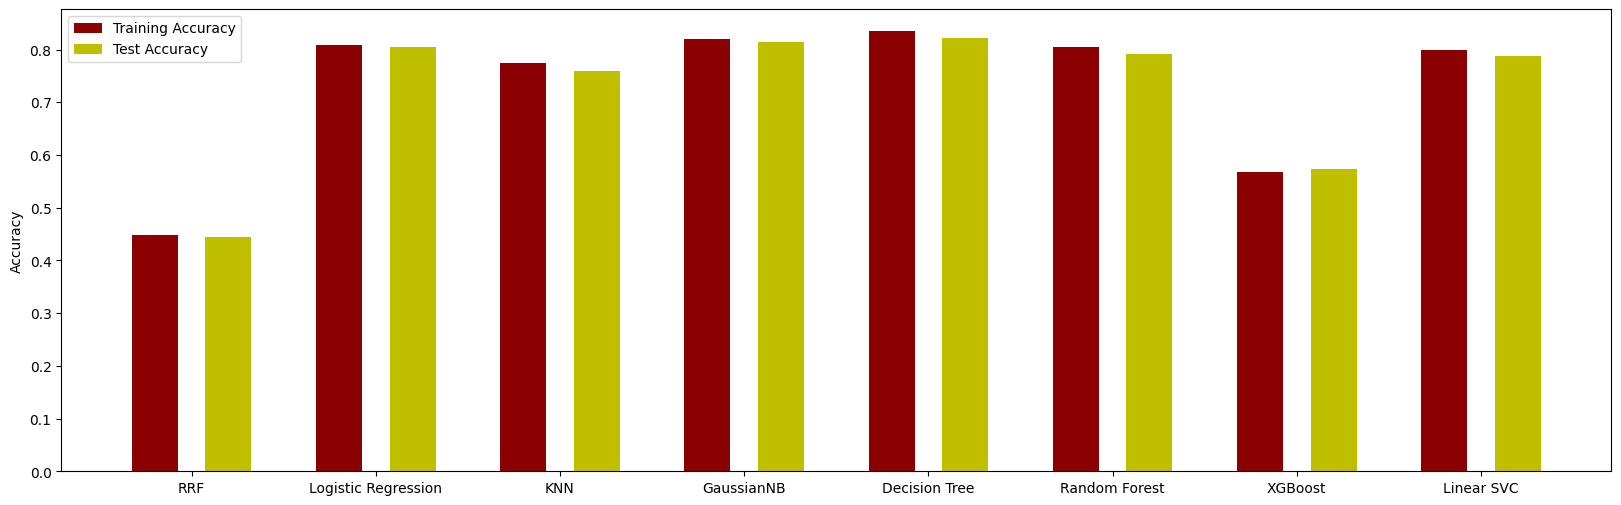

In [106]:
keys = [key for key in kernal_evals.keys()]
values = [value for value in kernal_evals.values()]
fig, ax = plt.subplots(figsize=(20, 6))
ax.bar(np.arange(len(keys)) - 0.2, [value[0] for value in values], color='darkred', width=0.25, align='center')
ax.bar(np.arange(len(keys)) + 0.2, [value[1] for value in values], color='y', width=0.25, align='center')
ax.legend(["Training Accuracy", "Test Accuracy"])
ax.set_xticklabels(keys)
ax.set_xticks(np.arange(len(keys)))
plt.ylabel("Accuracy")
plt.show()

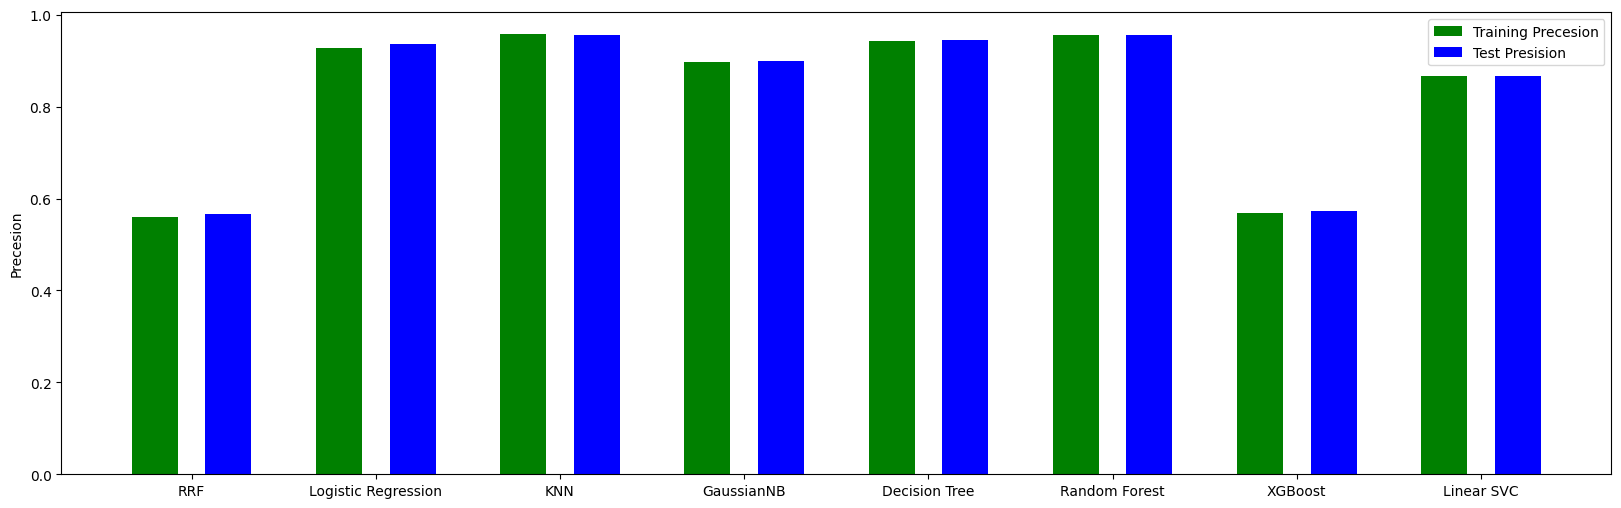

In [107]:
keys = [key for key in kernal_evals.keys()]
values = [value for value in kernal_evals.values()]
fig, ax = plt.subplots(figsize=(20, 6))
ax.bar(np.arange(len(keys)) - 0.2, [value[2] for value in values], color='g', width=0.25, align='center')
ax.bar(np.arange(len(keys)) + 0.2, [value[3] for value in values], color='b', width=0.25, align='center')
ax.legend(["Training Precesion", "Test Presision"])
ax.set_xticklabels(keys)
ax.set_xticks(np.arange(len(keys)))
plt.ylabel("Precesion")
plt.show()

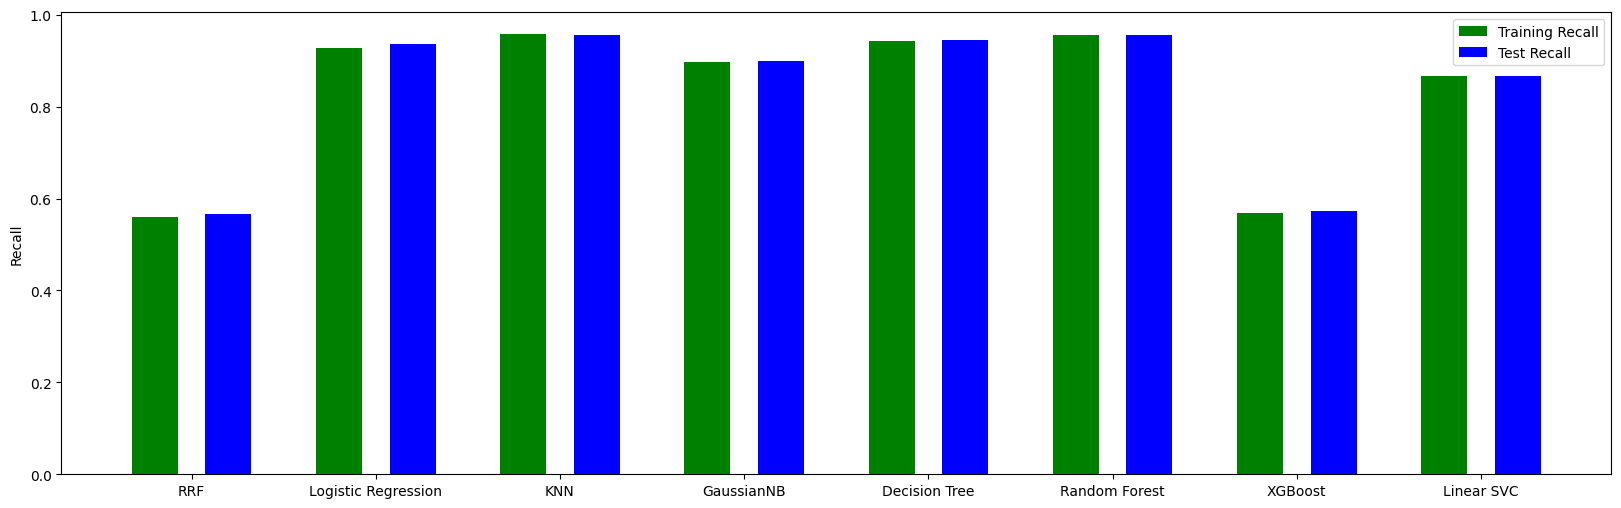

In [108]:
keys = [key for key in kernal_evals.keys()]
values = [value for value in kernal_evals.values()]
fig, ax = plt.subplots(figsize=(20, 6))
ax.bar(np.arange(len(keys)) - 0.2, [value[2] for value in values], color='g', width=0.25, align='center')
ax.bar(np.arange(len(keys)) + 0.2, [value[3] for value in values], color='b', width=0.25, align='center')
ax.legend(["Training Recall", "Test Recall"])
ax.set_xticklabels(keys)
ax.set_xticks(np.arange(len(keys)))
plt.ylabel("Recall")
plt.show()